# Autoencoder

## Import des libs

In [1]:
# Import de PyTorch
import torch
from torch import nn

# Import de TorchVision
import torchvision
from torchvision import datasets
from torchvision.transforms import ToTensor

# Import des outils
import matplotlib.pyplot as plt

print(f"PyTorch version : {torch.__version__}")
print(f"TorchVision version : {torchvision.__version__}")

PyTorch version : 2.11.0+cu126
TorchVision version : 0.26.0+cu126


## Le dataset

Fashion-MNIST est un ensemble de données d'images d'articles de Zalando, composé d'un ensemble d'apprentissage de 60 000 exemples et d'un ensemble de test de 10 000 exemples.

Chaque exemple est une image en niveaux de gris de 28x28, associée à une étiquette parmi 10 classes.

Zalando souhaite que Fashion-MNIST remplace directement l'ensemble de données MNIST original pour l'évaluation comparative des algorithmes d'apprentissage automatique.

Il partage la même taille d'image et la même structure de divisions d'entraînement et de test.

[Lien du dataset](https://www.kaggle.com/datasets/zalando-research/fashionmnist)

## Constantes

In [2]:
RANDOM_STATE = 42

IMAGE_HEIGHT = 28
IMAGE_WIDTH = 28
HIDDEN_DIM_1 = 150
HIDDEN_DIM_2 = 50
LATENT_SPACE_DIM = 2

## Obtenir les data de Fashion-MNIST

In [3]:
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=ToTensor(), target_transform=None)
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=ToTensor(), target_transform=None)

## Comprendre nos datas

In [4]:
print("Train :\n")
print(f"train_data.data : {train_data.data.shape}")
print(f"train_data.targets : {train_data.targets.shape}")

print("\nTest :\n")
print(f"test_data.data : {test_data.data.shape}")
print(f"test_data.targets : {test_data.targets.shape}")

Train :

train_data.data : torch.Size([60000, 28, 28])
train_data.targets : torch.Size([60000])

Test :

test_data.data : torch.Size([10000, 28, 28])
test_data.targets : torch.Size([10000])


In [5]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
class_names = [
 'T-shirt/top',
 'Pantalon',
 'Pull',
 'Robe',
 'Manteau',
 'Sandale',
 'Chemise',
 'Sneaker',
 'Sac',
 'Bottine'
]
class_names

['T-shirt/top',
 'Pantalon',
 'Pull',
 'Robe',
 'Manteau',
 'Sandale',
 'Chemise',
 'Sneaker',
 'Sac',
 'Bottine']

## Visualisation des datas

In [7]:
image, label = train_data[0]
print(f"image shape : {image.shape}")
print(f"label : {label}")

image shape : torch.Size([1, 28, 28])
label : 9


### Explication de la shape
[1, 28, 28] = [canal de couleur, hauteur, largeur]

Text(0.5, 1.0, 'Bottine')

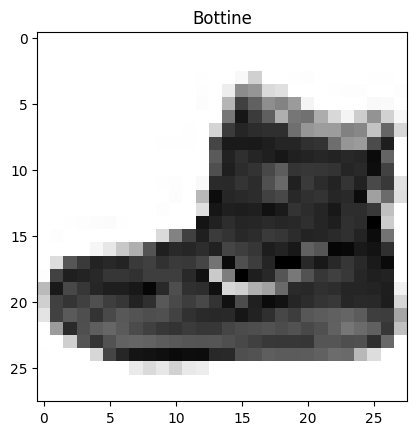

In [8]:
plt.imshow(image.squeeze(), cmap="Greys")
plt.title(class_names[label])

## Mise en oeuvre de la data sous forme de Mini-Batchs

In [9]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

### Comprendre nos Mini-Batch

In [10]:
print(f"Longueur du train dataloader: {len(train_dataloader)} mini-batchs de {BATCH_SIZE} éléments")
print(f"Longueur du test dataloader: {len(test_dataloader)} mini-batchs de {BATCH_SIZE} éléments")

Longueur du train dataloader: 1875 mini-batchs de 32 éléments
Longueur du test dataloader: 313 mini-batchs de 32 éléments


In [11]:
train_elements_batch, train_labels_batch = next(iter(train_dataloader))
print(f"train_elements_batch : {train_elements_batch.shape}")
print(f"train_labels_batch : {train_labels_batch.shape}")

train_elements_batch : torch.Size([32, 1, 28, 28])
train_labels_batch : torch.Size([32])


#### Explication de la shape
[32, 1, 28, 28] = [éléments du batch, canal de couleur, hauteur, largeur]

[32] = [labels du batch]

## Création du modèle de l'autoencoder

### On utilise la carte graphique (le GPU)

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### On va transformer notre image en un vecteur

In [13]:
train_element = train_elements_batch[0]
print(f"Shape avant le flattening : {train_element.shape} -> [canal_couleur, hauteur, largeur]")

Shape avant le flattening : torch.Size([1, 28, 28]) -> [canal_couleur, hauteur, largeur]


In [14]:
flatten_model = nn.Flatten()
output = flatten_model(train_element)
print(f"Shape après le flattening: {output.shape} -> [canal_couleur, hauteur * largeur]")

Shape après le flattening: torch.Size([1, 784]) -> [canal_couleur, hauteur * largeur]


In [15]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(IMAGE_HEIGHT*IMAGE_WIDTH, HIDDEN_DIM_1),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_1, HIDDEN_DIM_2),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_2, LATENT_SPACE_DIM)
        )
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_SPACE_DIM, HIDDEN_DIM_2),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_2, HIDDEN_DIM_1),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM_1, IMAGE_HEIGHT*IMAGE_WIDTH),
            nn.Sigmoid(),
            nn.Unflatten(dim=1, unflattened_size=(1, 28, 28))
        )
    
    def forward(self, x: torch.Tensor):
        latent = self.encoder(x)
        x_hat = self.decoder(latent)
        return x_hat

In [16]:
autoEncoder = AutoEncoder().to(device)
next(autoEncoder.parameters()).device

device(type='cuda', index=0)

In [17]:
from torchsummary import summary

summary(autoEncoder, input_size=(1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 150]         117,750
              ReLU-3                  [-1, 150]               0
            Linear-4                   [-1, 50]           7,550
              ReLU-5                   [-1, 50]               0
            Linear-6                    [-1, 2]             102
            Linear-7                   [-1, 50]             150
              ReLU-8                   [-1, 50]               0
            Linear-9                  [-1, 150]           7,650
             ReLU-10                  [-1, 150]               0
           Linear-11                  [-1, 784]         118,384
          Sigmoid-12                  [-1, 784]               0
        Unflatten-13            [-1, 1, 28, 28]               0
Total params: 251,586
Trainable params:

### Loss et optimizer

In [18]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params=autoEncoder.parameters(), lr=0.001)

### Phase d'entrainement

In [19]:
from timeit import default_timer as timer
from my_helper_functions import print_train_time, plot_training_data, train

# Initialisation
train_start = timer()

results = train(model=autoEncoder, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer=optimizer, loss_fn=loss_fn, epochs=20, device=device)

train_end = timer()
train_time_autoEncoder = print_train_time(start=train_start, end=train_end, device=device)

c:\Users\remi_\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  5%|▌         | 1/20 [00:14<04:35, 14.48s/it]

Epoch: 1 | train_loss: 0.0364 | test_loss: 0.0304 | 


 10%|█         | 2/20 [00:28<04:18, 14.33s/it]

Epoch: 2 | train_loss: 0.0294 | test_loss: 0.0288 | 


 15%|█▌        | 3/20 [00:42<04:03, 14.31s/it]

...

Epoch: 18 | train_loss: 0.0252 | test_loss: 0.0252 | 


 95%|█████████▌| 19/20 [04:38<00:15, 15.07s/it]

Epoch: 19 | train_loss: 0.0249 | test_loss: 0.0253 | 


100%|██████████| 20/20 [04:53<00:00, 14.69s/it]

Epoch: 20 | train_loss: 0.0250 | test_loss: 0.0252 | 
Train time on cuda: 293.751 seconds


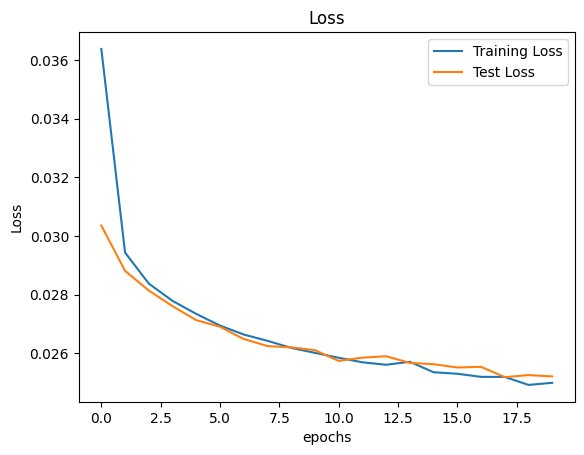

In [20]:
plot_training_data("Loss", results["train_loss"], results["test_loss"])

## Visualiser la reconstruction

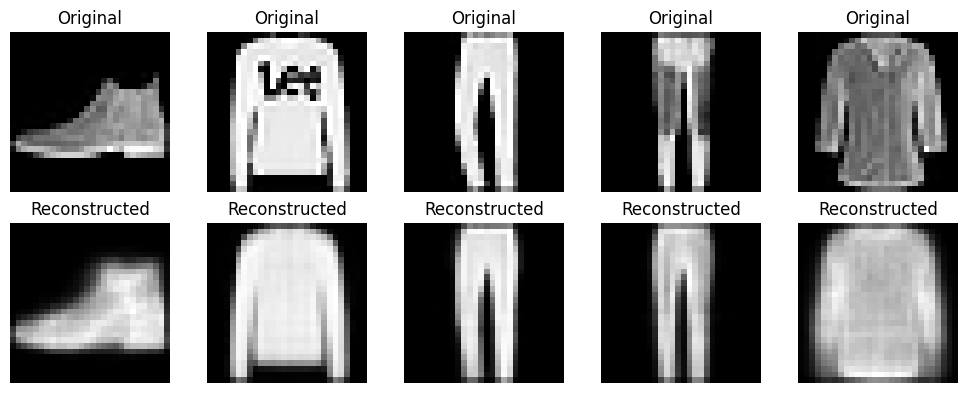

In [21]:
# Mettre le modèle en mode éval
autoEncoder.eval()

# Prendre un batch
X, _ = next(iter(test_dataloader))
X = X.to(device)

# Désactiver le gradient
with torch.inference_mode():
    x_hat = autoEncoder(X)

# Repasser sur CPU pour affichage
X = X.cpu()
x_hat = x_hat.cpu()

# Nombre d'images à afficher
n = 5

plt.figure(figsize=(10, 4))

for i in range(n):
    # Image originale
    plt.subplot(2, n, i + 1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Image reconstruite
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_hat[i].squeeze(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Visualiser l'espace latent

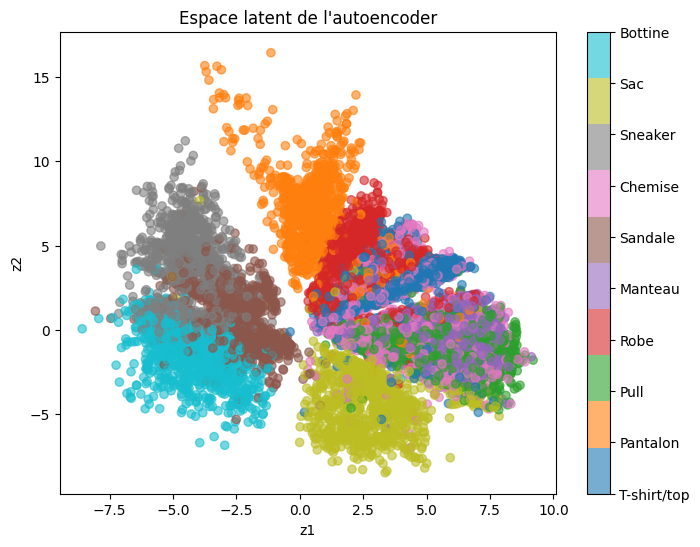

In [22]:
autoEncoder.eval()

latent_points = []
labels_list = []

with torch.inference_mode():
    for X, y in test_dataloader:
        X = X.to(device)

        z = autoEncoder.encoder(X)

        latent_points.append(z.cpu())
        labels_list.append(y.cpu())

latent_points = torch.cat(latent_points, dim=0)
labels_list = torch.cat(labels_list, dim=0)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=labels_list,
    cmap="tab10",
    alpha=0.6
)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Espace latent de l'autoencoder")

# 🎯 Remplacement des indices par les noms
cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)

plt.show()

## Génération à partir de l'espace latent

In [ ]:

# 4 coordonnées choisies dans l'espace latent
z_selected = torch.tensor([
    [-4.5, -2.0],  # zone Bottine
    [ 3.0, 2.0],   # zone T-shirt
    [ 0.5, 8.0],   # zone Pantalon
    [ 2.5, -5.0],  # zone Sac
], dtype=torch.float32)

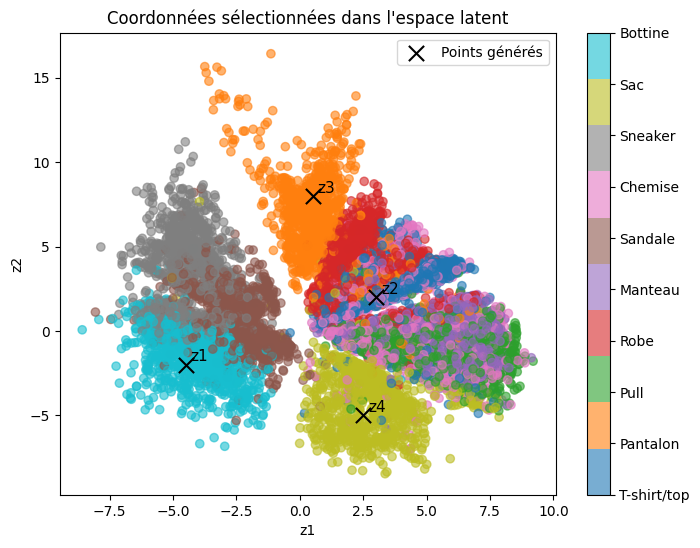

In [26]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=labels_list,
    cmap="tab10",
    alpha=0.6
)

plt.scatter(
    z_selected[:, 0],
    z_selected[:, 1],
    color="black",
    marker="x",
    s=120,
    label="Points générés"
)

for i, z in enumerate(z_selected):
    plt.text(z[0] + 0.2, z[1] + 0.2, f"z{i+1}", fontsize=11)

plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Coordonnées sélectionnées dans l'espace latent")

cbar = plt.colorbar(scatter, ticks=range(len(class_names)))
cbar.ax.set_yticklabels(class_names)

plt.legend()
plt.show()

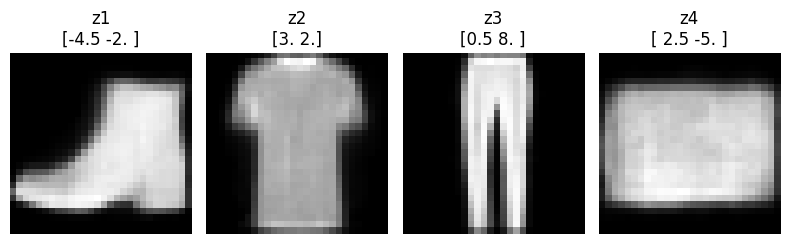

In [27]:
z_selected = z_selected.to(device)

with torch.inference_mode():
    generated = autoEncoder.decoder(z_selected)

generated = generated.cpu()
z_selected_cpu = z_selected.cpu()

plt.figure(figsize=(8, 3))

for i in range(len(generated)):
    plt.subplot(1, 4, i + 1)
    plt.imshow(generated[i].squeeze(), cmap="gray")
    plt.title(f"z{i+1}\n{z_selected_cpu[i].numpy()}")
    plt.axis("off")

plt.tight_layout()
plt.show()